In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def group_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))
            
            curr_results = pd.read_csv(dir_path + file)

            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha

            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['soglia_ctr','alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum', 'est_clicks': 'sum', 'est_impressions': 'sum'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    grouped_results_run_iter['true_ctr'] = grouped_results_run_iter['true_clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_publisher()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['true_clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['impressions'])
    # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['ctr'])
    grouped_results['true_ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['true_ctr']
    grouped_results['true_ctr_ci'] = 1.96 * grouped_results['true_ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['true_ctr'])
    # estimated clicks
    grouped_results['est_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['est_clicks']
    grouped_results['est_clicks_ci'] = 1.96 * grouped_results['est_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['est_clicks'])
    # estimated impressions
    grouped_results['est_impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['est_impressions']
    grouped_results['est_impressions_ci'] = 1.96 * grouped_results['est_impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['est_impressions'])
    return grouped_results

In [3]:
def read_all_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    files_per_alpha = {}
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            if alpha not in files_per_alpha:
                files_per_alpha[alpha] = [file]
            else:
                files_per_alpha[alpha].append(file)
    # Load the results
    results = pd.DataFrame()
    for alpha, files in files_per_alpha.items():
        for file in files:
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            results = pd.concat([results, curr_results])
    return results

In [4]:
def get_pub_estimates(data):
    group_pub = data[data['Iteration']>1].groupby(['publisher']).agg({'est_clicks': 'mean', 'est_impressions': 'mean'}).reset_index()
    group_pub['est_clicks_std'] = data.groupby(['publisher']).agg({'est_clicks':'std'}).reset_index()['est_clicks']
    group_pub['est_clicks_ci'] = 1.96 * group_pub['est_clicks_std'] / np.sqrt(data.groupby(['publisher']).agg({'est_clicks':'count'}).reset_index()['est_clicks'])
    # estimated impressions
    group_pub['est_impressions_std'] = data.groupby(['publisher']).agg({'est_impressions':'std'}).reset_index()['est_impressions']
    group_pub['est_impressions_ci'] = 1.96 * group_pub['est_impressions_std'] / np.sqrt(data.groupby(['publisher']).agg({'est_impressions':'count'}).reset_index()['est_impressions'])
    return group_pub

In [67]:
linucb_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_97_20_11_24_nuovasoglia/'

In [68]:
linucb_res = read_all_data(linucb_dir_path)

In [69]:
linucb_pub_est = get_pub_estimates(linucb_res)

In [70]:
cucb_dir_path = '../results/FP_Truthful_Oracle_sigmoids_cucb_textemb_ctr_0_97_19_11_24/'

In [71]:
cucb_res = read_all_data(cucb_dir_path)
cucb_pub_est = get_pub_estimates(cucb_res)

In [41]:
# Verifico che ci siano gli stessi publisher
assert set(linucb_pub_est['publisher']) == set(cucb_pub_est['publisher'])

AssertionError: 

In [77]:
def plot_pub_estimates(linucb_pub_estimates, cucb_pub_estimates, estimated_quantity='est_clicks'):
    # Order the publishers
    linucb_pub_estimates = linucb_pub_estimates.sort_values(by=estimated_quantity, ascending=False)
    cucb_pub_estimates = cucb_pub_estimates.sort_values(by=estimated_quantity, ascending=False)
    # Filtra solo i publisher comuni
    linucb_pubs = set(linucb_pub_estimates['publisher'])
    cucb_pubs = set(cucb_pub_estimates['publisher'])
    common_pubs = linucb_pubs.intersection(cucb_pubs)
    print(f'Number of common publishers: {len(common_pubs)}')
    linucb_common_pub_estimates = linucb_pub_estimates[linucb_pub_estimates['publisher'].isin(common_pubs)]
    cucb_common_pub_estimates = cucb_pub_estimates[cucb_pub_estimates['publisher'].isin(common_pubs)]
    fig, ax = plt.subplots()
    fig.set_size_inches(18.5, 10.5)
    ax.set_title(f'{estimated_quantity} estimates')
    #ax.scatter(cucb_common_pub_estimates['publisher'], cucb_common_pub_estimates[estimated_quantity], label='CUCB')
    ax.errorbar(cucb_common_pub_estimates['publisher'], cucb_common_pub_estimates[estimated_quantity], yerr=cucb_common_pub_estimates[estimated_quantity+'_ci'], fmt='o', label='CUCB')
    #ax.scatter(linucb_common_pub_estimates['publisher'], linucb_common_pub_estimates[estimated_quantity], label='LinUCB')
    ax.errorbar(linucb_common_pub_estimates['publisher'], linucb_common_pub_estimates[estimated_quantity], yerr=linucb_common_pub_estimates[estimated_quantity+'_ci'], fmt='o', label='LinUCB')
    ax.set_xlabel('Publisher')
    ax.set_ylabel('Estimated Clicks')
    plt.xticks(rotation=90)
    ax.legend()
    plt.show()

Number of common publishers: 44


/home/azureuser/auction-gym/venv/lib/python3.12/site-packages/numpy/core/_methods.py:45: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/home/azureuser/auction-gym/venv/lib/python3.12/site-packages/numpy/core/_methods.py:41: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


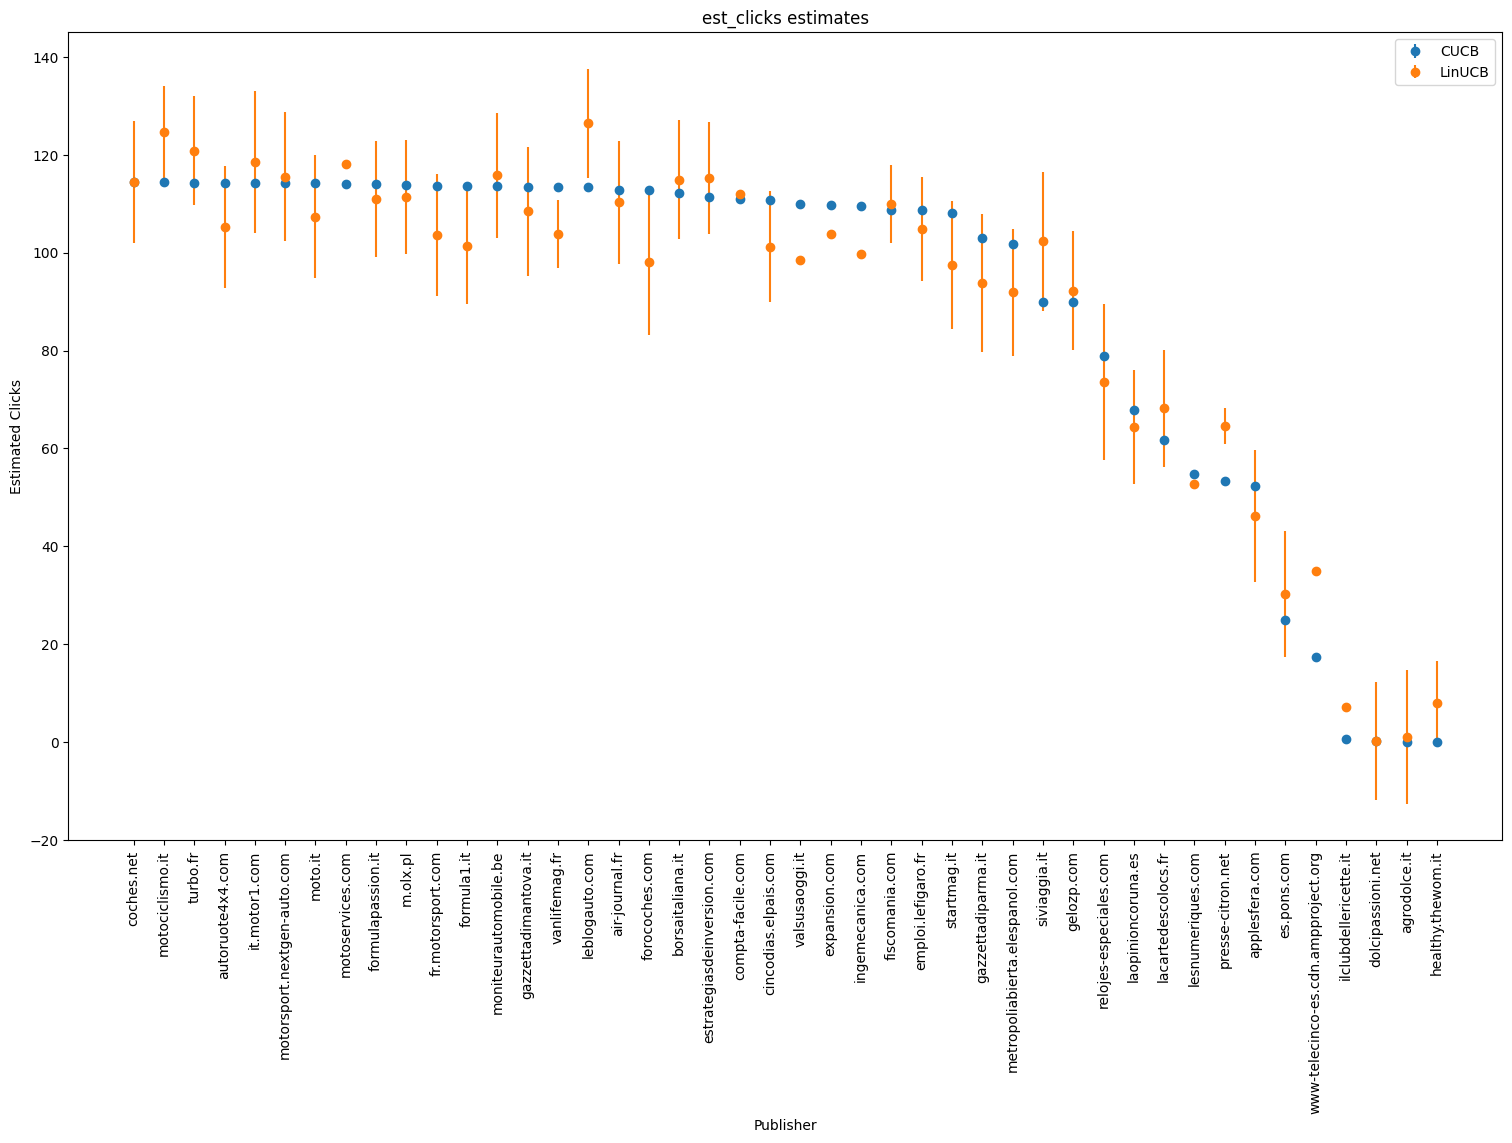

In [78]:
plot_pub_estimates(linucb_pub_estimates=linucb_pub_est, cucb_pub_estimates=cucb_pub_est)

Number of common publishers: 44


/home/azureuser/auction-gym/venv/lib/python3.12/site-packages/numpy/core/_methods.py:45: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/home/azureuser/auction-gym/venv/lib/python3.12/site-packages/numpy/core/_methods.py:41: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


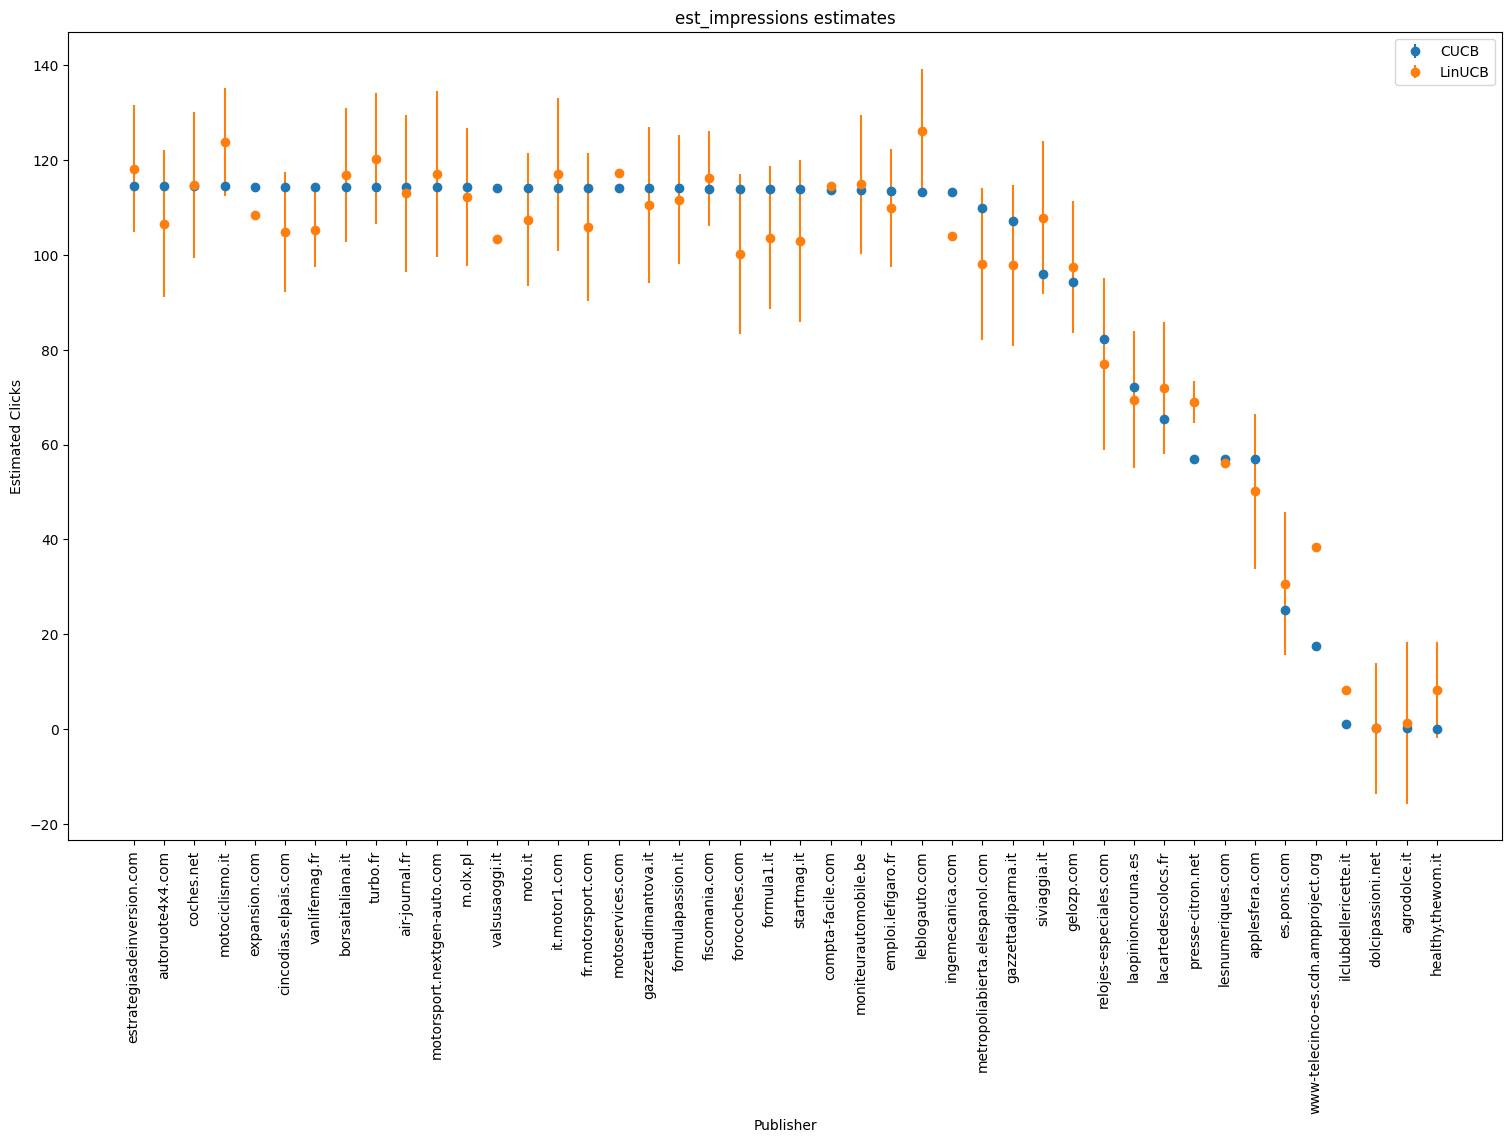

In [79]:
plot_pub_estimates(linucb_pub_estimates=linucb_pub_est, cucb_pub_estimates=cucb_pub_est, estimated_quantity='est_impressions')

In [22]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def get_linucb_predictions(
        result_dir_path: str, 
        publisher_embeddings: dict,
        theta_click_path: str = 'linucb_theta_click_run_0_ctr_0.9_alpha_1.pkl',
        theta_impression_path: str = 'linucb_theta_impressions_run_0_ctr_0.9_alpha_1.pkl',
        is_log_predictions: bool = False
) -> pd.DataFrame:
    linucb_theta_click = pickle.load(open(f'{result_dir_path}{theta_click_path}', 'rb'))
    linucb_theta_impression = pickle.load(open(f'{result_dir_path}{theta_impression_path}', 'rb'))
    linucb_predictions = []
    for pub, emb in publisher_embeddings.items():
        if is_log_predictions:
            click_prediction = np.exp(np.dot(emb, linucb_theta_click))
            impression_prediction = np.exp(np.dot(emb, linucb_theta_impression))
        else:
            click_prediction = np.dot(emb, linucb_theta_click)
            impression_prediction = np.dot(emb, linucb_theta_impression)
        curr_pred = {'publisher': pub, 'clicks': click_prediction, 'impressions': impression_prediction}
        linucb_predictions.append(curr_pred)
    linucb_predictions_df = pd.DataFrame(linucb_predictions)
    linucb_predictions_df['ctr'] = linucb_predictions_df['clicks'] / linucb_predictions_df['impressions']
    return linucb_predictions_df

In [14]:
pub_embeddings_path = '../src/publisher_embedding/data/embeddings_to_pick/sites_embeddings_red_70.pkl'
pub_embeddings = pickle.load(open(pub_embeddings_path, 'rb'))

In [26]:
linucb_results_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_99_06_12_24/'
linucb_predictions = get_linucb_predictions(
    result_dir_path=linucb_results_dir,
    publisher_embeddings=pub_embeddings,
    theta_click_path='linucb_theta_click_run_0_ctr_0.99_alpha_1.pkl',
    theta_impression_path='linucb_theta_impressions_run_0_ctr_0.99_alpha_1.pkl'
)

In [17]:
linucb_logpred_results_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_97_05_12_24_logpred/'
linucb_logpred_predictions = get_linucb_predictions(
    result_dir_path=linucb_logpred_results_dir_path,
    publisher_embeddings=pub_embeddings,
    theta_click_path='linucb_theta_click_run_0_ctr_0.97_alpha_1.pkl',
    theta_impression_path='linucb_theta_impressions_run_0_ctr_0.97_alpha_1.pkl',
    is_log_predictions=True
)

In [27]:
pub_emb_rescaled = pickle.load(open('../src/publisher_embedding/data/embeddings_to_pick/sites_embeddings_red_70_scaled.pkl', 'rb'))
linucb_rescaled_predictions = get_linucb_predictions(
    result_dir_path='../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_99_06_12_24/',
    publisher_embeddings=pub_emb_rescaled,
    theta_click_path='linucb_theta_click_run_0_ctr_0.99_alpha_1.pkl',
    theta_impression_path='linucb_theta_impressions_run_0_ctr_0.99_alpha_1.pkl'
)

In [28]:
cucb_results_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_textemb_ctr_0_99_05_12_24_nuovoagent/'
cucb_click_path = f'{cucb_results_dir}cucb_est_click_run_0_ctr_0.99_alpha_1.pkl'
cucb_impression_path = f'{cucb_results_dir}cucb_est_impressions_run_0_ctr_0.99_alpha_1.pkl'
cucb_click = pickle.load(open(cucb_click_path, 'rb'))
cucb_impression = pickle.load(open(cucb_impression_path, 'rb'))

cucb_click_df = pd.DataFrame(list(cucb_click.items()), columns=['publisher', 'clicks'])
cucb_impression_df = pd.DataFrame(list(cucb_impression.items()), columns=['publisher', 'impressions'])

cucb_predictions_df = pd.merge(cucb_click_df, cucb_impression_df, on='publisher')
cucb_predictions_df['ctr'] = cucb_predictions_df['clicks'] / cucb_predictions_df['impressions']

In [20]:
def plot_predictions(linucb_predictions, cucb_predictions, linucb_log_predictions=None, estimated_quantity='clicks'):
    # Order cucb predictions from the highest to the lowest
    cucb_predictions = cucb_predictions.sort_values(by=estimated_quantity, ascending=False)
    # Order linucb predictions from the publisher with the highest cucb prediction to the lowest
    # cucb_pub_list = cucb_predictions['publisher']
    # linucb_predictions = linucb_predictions.set_index('publisher').loc[cucb_pub_list].reset_index()
    
    pub_ordered = cucb_predictions['publisher'].values
    linucb_predictions = linucb_predictions[linucb_predictions['publisher'].isin(pub_ordered)]
    linucb_predictions['publisher'] = pd.Categorical(linucb_predictions['publisher'], categories=pub_ordered, ordered=True)
    linucb_predictions = linucb_predictions.sort_values(by='publisher')
    if linucb_log_predictions is not None:
        linucb_log_predictions = linucb_log_predictions[linucb_log_predictions['publisher'].isin(pub_ordered)]
        linucb_log_predictions['publisher'] = pd.Categorical(linucb_log_predictions['publisher'], categories=pub_ordered, ordered=True)
        linucb_log_predictions = linucb_log_predictions.sort_values(by='publisher')
    plt.figure(figsize=(25, 10.5))
    plt.plot(cucb_predictions['publisher'].to_numpy(), cucb_predictions[estimated_quantity].to_numpy(), label='CUCB')
    plt.plot(cucb_predictions['publisher'].to_numpy(), linucb_predictions[estimated_quantity].to_numpy(), label='LinUCB')
    if linucb_log_predictions is not None:
        plt.plot(cucb_predictions['publisher'].to_numpy(), linucb_log_predictions[estimated_quantity].to_numpy(), label='LinUCB LogPred')
    plt.axhline(y=0, color='black', linestyle='--')
    if estimated_quantity == 'ctr':
        plt.axhline(y=1, color='black', linestyle='--')
    plt.xlabel('Publisher')
    plt.ylabel(f'Estimated {estimated_quantity}')
    plt.gca().set_xticklabels([])
    plt.legend()
    plt.show()

/tmp/ipykernel_62501/2140540348.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_predictions['publisher'] = pd.Categorical(linucb_predictions['publisher'], categories=pub_ordered, ordered=True)
/tmp/ipykernel_62501/2140540348.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_log_predictions['publisher'] = pd.Categorical(linucb_log_predictions['publisher'], categories=pub_ordered, ordered=True)


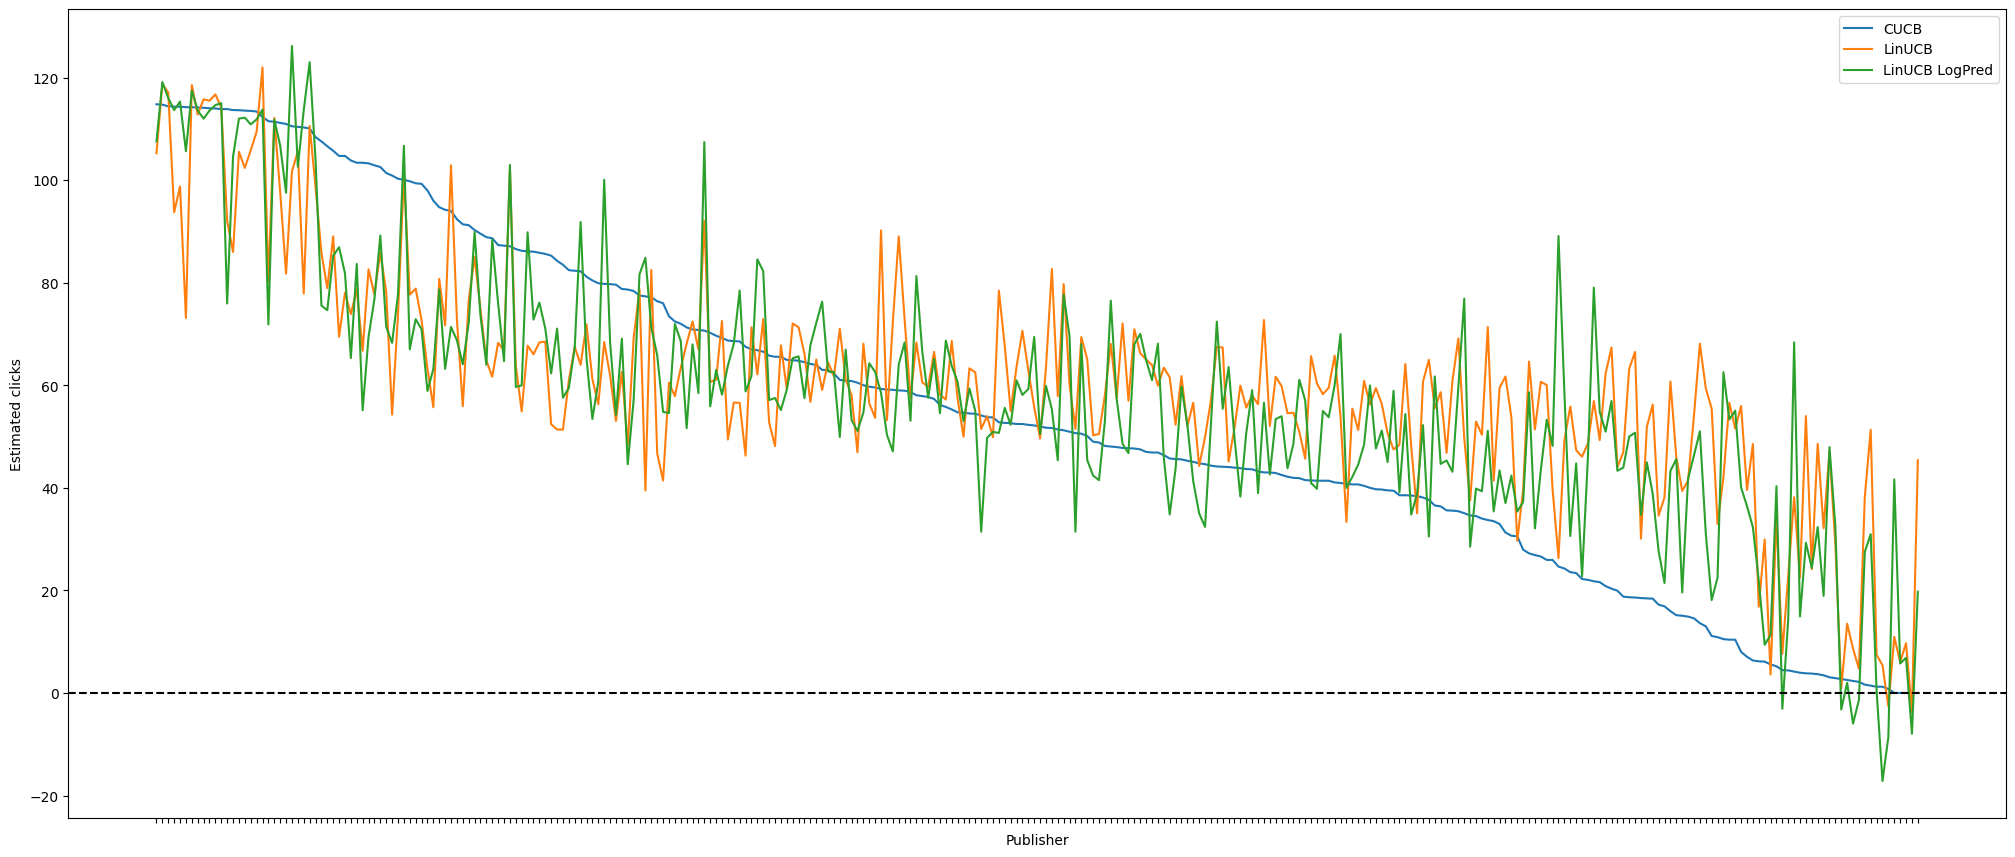

In [29]:
plot_predictions(linucb_predictions, cucb_predictions_df, linucb_rescaled_predictions, estimated_quantity='clicks')

/tmp/ipykernel_1633/2140540348.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_predictions['publisher'] = pd.Categorical(linucb_predictions['publisher'], categories=pub_ordered, ordered=True)


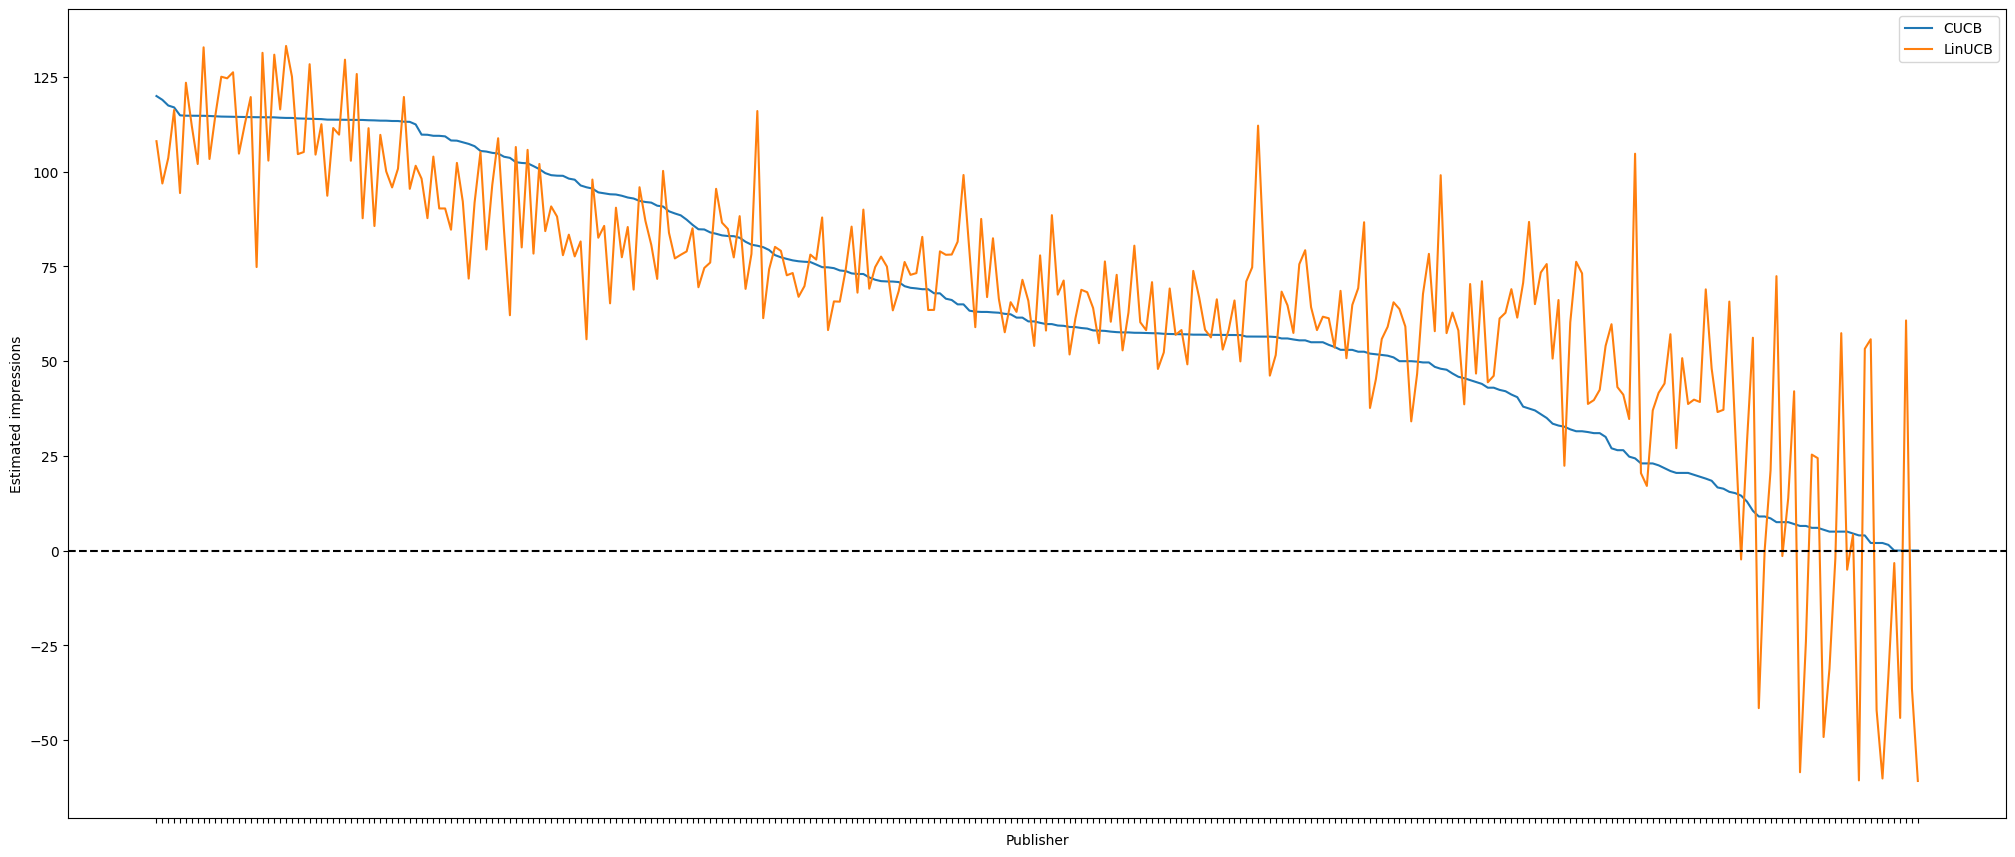

In [66]:
plot_predictions(linucb_predictions_df, cucb_predictions_df, estimated_quantity='impressions')

/tmp/ipykernel_62501/2140540348.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_predictions['publisher'] = pd.Categorical(linucb_predictions['publisher'], categories=pub_ordered, ordered=True)
/tmp/ipykernel_62501/2140540348.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_log_predictions['publisher'] = pd.Categorical(linucb_log_predictions['publisher'], categories=pub_ordered, ordered=True)


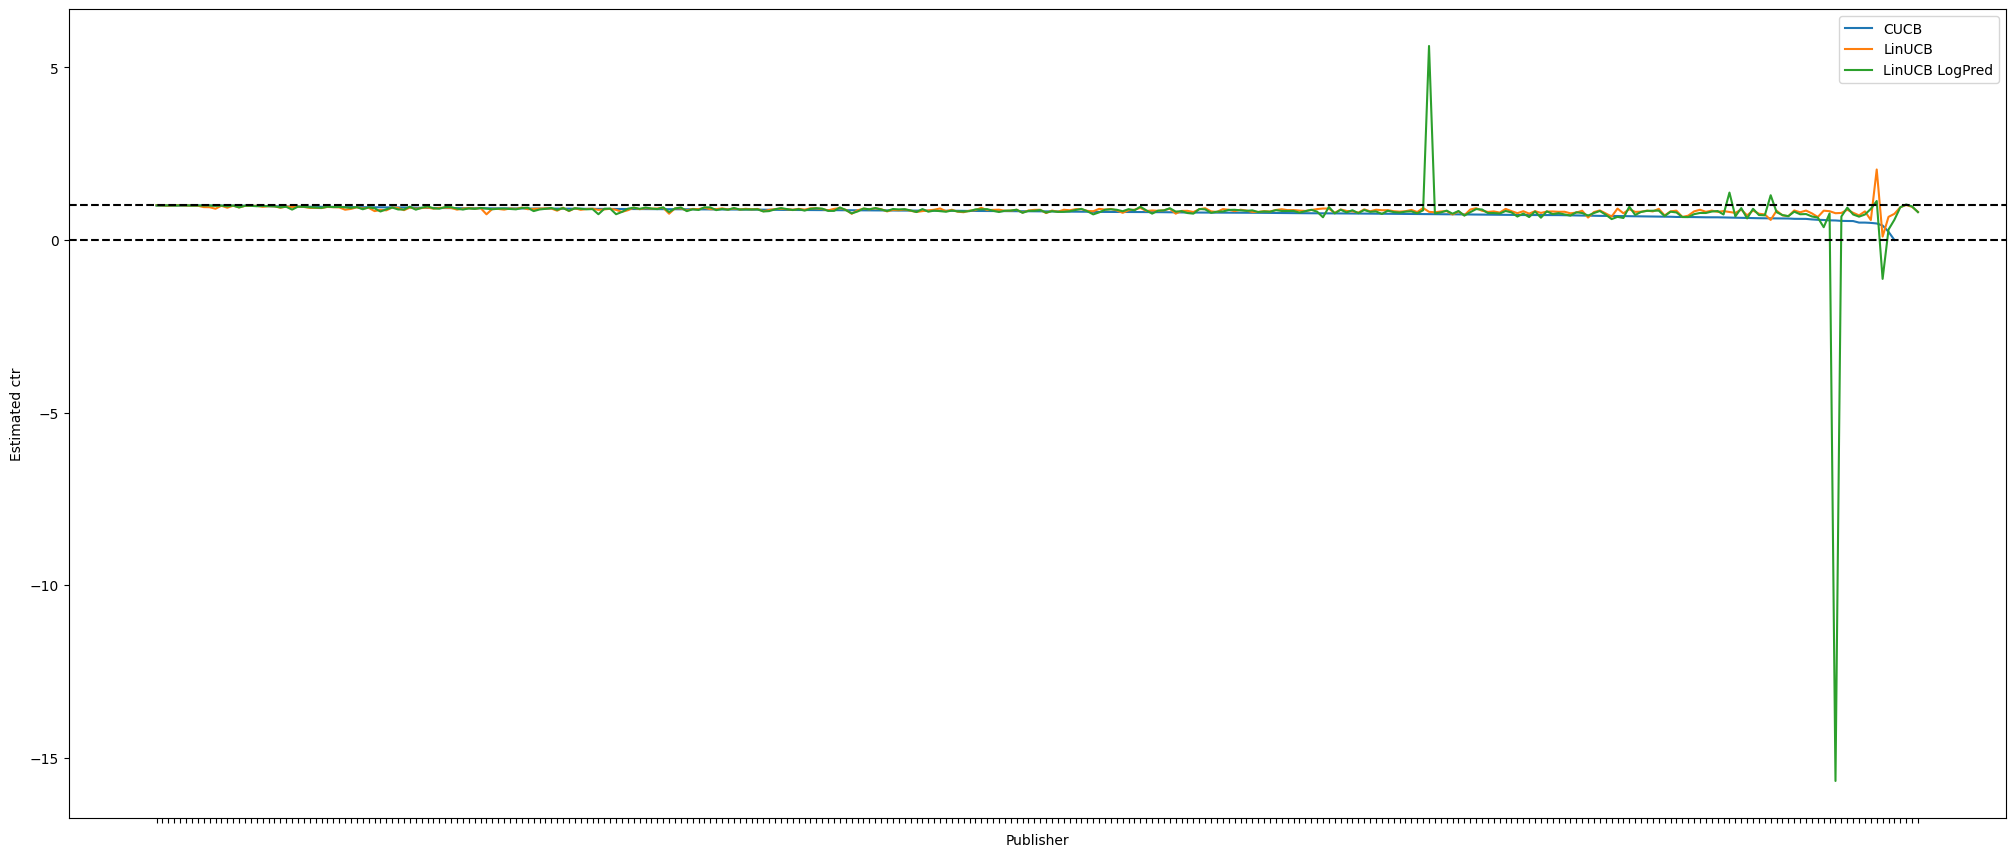

In [30]:
plot_predictions(linucb_predictions, cucb_predictions_df, linucb_rescaled_predictions, estimated_quantity='ctr')